In [1]:
# Cell 1 — Imports & Load Master Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = r'C:\Users\rs074\battery-soh-platform\data\battery_master.csv'
df = pd.read_csv(DATA_PATH)

print(f'Data loaded ✓ — Shape: {df.shape}')
print(f'Batteries: {df["Battery"].unique()}')
print(f'Columns: {list(df.columns)}')

Data loaded ✓ — Shape: (636, 15)
Batteries: ['B0005' 'B0006' 'B0007' 'B0018']
Columns: ['cycle_raw', 'avg_voltage', 'min_voltage', 'max_voltage', 'voltage_drop', 'avg_current', 'avg_temp', 'max_temp', 'temp_rise', 'discharge_time', 'Battery', 'Cycle_Index', 'Capacity', 'SoH', 'RUL']


In [2]:
# Cell 2 — Rolling Window Features
# Rolling features capture TREND not just current value
# e.g. "capacity has been falling for 5 cycles" is more powerful than "capacity is X"

df = df.sort_values(['Battery', 'Cycle_Index']).reset_index(drop=True)

for battery in df['Battery'].unique():
    mask = df['Battery'] == battery
    
    # 5-cycle rolling features
    df.loc[mask, 'rolling_avg_capacity'] = df.loc[mask, 'Capacity'].rolling(5, min_periods=1).mean()
    df.loc[mask, 'rolling_std_capacity'] = df.loc[mask, 'Capacity'].rolling(5, min_periods=1).std().fillna(0)
    df.loc[mask, 'rolling_avg_voltage']  = df.loc[mask, 'avg_voltage'].rolling(5, min_periods=1).mean()
    df.loc[mask, 'rolling_avg_temp']     = df.loc[mask, 'avg_temp'].rolling(5, min_periods=1).mean()
    df.loc[mask, 'rolling_discharge_time'] = df.loc[mask, 'discharge_time'].rolling(5, min_periods=1).mean()
    
    # Capacity fade rate (how fast is it dropping?)
    df.loc[mask, 'capacity_fade_rate'] = df.loc[mask, 'Capacity'].diff().fillna(0)
    df.loc[mask, 'voltage_fade_rate']  = df.loc[mask, 'avg_voltage'].diff().fillna(0)
    df.loc[mask, 'temp_increase_rate'] = df.loc[mask, 'avg_temp'].diff().fillna(0)

print('Rolling features created ✓')
print(f'New shape: {df.shape}')
print(f'\nNew columns added:')
new_cols = ['rolling_avg_capacity', 'rolling_std_capacity', 'rolling_avg_voltage',
            'rolling_avg_temp', 'rolling_discharge_time', 'capacity_fade_rate',
            'voltage_fade_rate', 'temp_increase_rate']
for col in new_cols:
    print(f'  - {col}: {df[col].mean():.4f} avg')

Rolling features created ✓
New shape: (636, 23)

New columns added:
  - rolling_avg_capacity: 1.5891 avg
  - rolling_std_capacity: 0.0138 avg
  - rolling_avg_voltage: 3.4997 avg
  - rolling_avg_temp: 32.3196 avg
  - rolling_discharge_time: 3127.3524 avg
  - capacity_fade_rate: -0.0037 avg
  - voltage_fade_rate: -0.0005 avg
  - temp_increase_rate: 0.0045 avg


In [3]:
# Cell 3 — Advanced Health Indicators
# These are the features BMS engineers actually use in real systems

for battery in df['Battery'].unique():
    mask = df['Battery'] == battery
    
    # Internal resistance estimate
    # As battery ages, internal resistance increases
    # Approximated as voltage_drop / avg_current
    df.loc[mask, 'internal_resistance'] = (
        df.loc[mask, 'voltage_drop'] / df.loc[mask, 'avg_current']
    )
    
    # Energy delivered per cycle (Wh)
    # = avg_voltage × avg_current × discharge_time / 3600
    df.loc[mask, 'energy_delivered'] = (
        df.loc[mask, 'avg_voltage'] *
        df.loc[mask, 'avg_current'] *
        df.loc[mask, 'discharge_time'] / 3600
    )
    
    # Cumulative energy delivered (total stress on battery)
    df.loc[mask, 'cumulative_energy'] = df.loc[mask, 'energy_delivered'].cumsum()
    
    # Capacity retention ratio (vs initial capacity)
    initial_cap = df.loc[mask, 'Capacity'].iloc[0]
    df.loc[mask, 'capacity_retention'] = df.loc[mask, 'Capacity'] / initial_cap
    
    # Discharge efficiency (discharge_time normalized)
    max_time = df.loc[mask, 'discharge_time'].iloc[0]
    df.loc[mask, 'discharge_efficiency'] = df.loc[mask, 'discharge_time'] / max_time
    
    # Thermal stress indicator
    df.loc[mask, 'thermal_stress'] = (
        df.loc[mask, 'max_temp'] * df.loc[mask, 'temp_rise']
    )
    
    # Cycle life percentage (how far through its life)
    total_cycles = mask.sum()
    df.loc[mask, 'life_percentage'] = (
        df.loc[mask, 'Cycle_Index'] / total_cycles * 100
    )

print('Advanced health indicators created ✓')
print(f'New shape: {df.shape}')
print(f'\nSample health indicators for B0005 cycle 50:')
b5_50 = df[(df['Battery']=='B0005') & (df['Cycle_Index']==50)].iloc[0]
print(f'  Internal resistance : {b5_50["internal_resistance"]:.4f} Ω')
print(f'  Energy delivered    : {b5_50["energy_delivered"]:.4f} Wh')
print(f'  Cumulative energy   : {b5_50["cumulative_energy"]:.2f} Wh')
print(f'  Capacity retention  : {b5_50["capacity_retention"]*100:.2f}%')
print(f'  Discharge efficiency: {b5_50["discharge_efficiency"]*100:.2f}%')
print(f'  Thermal stress      : {b5_50["thermal_stress"]:.2f}')

Advanced health indicators created ✓
New shape: (636, 30)

Sample health indicators for B0005 cycle 50:
  Internal resistance : 0.8141 Ω
  Energy delivered    : 6.2439 Wh
  Cumulative energy   : 327.71 Wh
  Capacity retention  : 94.64%
  Discharge efficiency: 88.98%
  Thermal stress      : 568.30


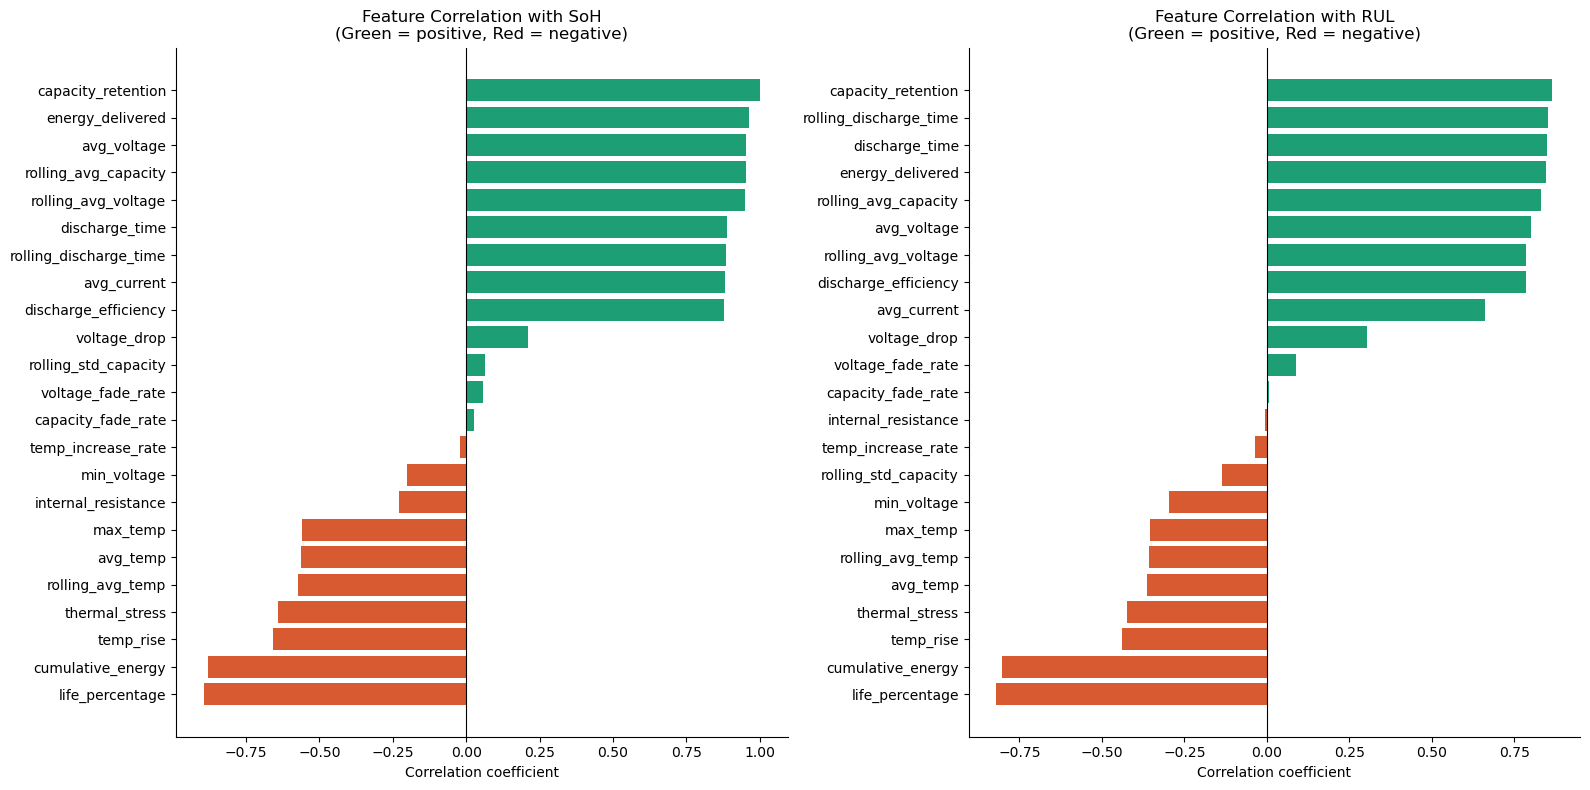


Top 5 features correlated with SoH:
capacity_retention      1.000000
energy_delivered        0.963364
avg_voltage             0.954996
rolling_avg_capacity    0.953045
rolling_avg_voltage     0.950247
Name: SoH, dtype: float64

Top 5 features correlated with RUL:
capacity_retention        0.865034
rolling_discharge_time    0.851865
discharge_time            0.849673
energy_delivered          0.844791
rolling_avg_capacity      0.831608
Name: RUL, dtype: float64


In [4]:
# Cell 4 — Feature Correlation with SoH & RUL
feature_cols = [
    'avg_voltage', 'min_voltage', 'voltage_drop', 'avg_current',
    'avg_temp', 'max_temp', 'temp_rise', 'discharge_time',
    'rolling_avg_capacity', 'rolling_std_capacity', 'rolling_avg_voltage',
    'rolling_avg_temp', 'rolling_discharge_time', 'capacity_fade_rate',
    'voltage_fade_rate', 'temp_increase_rate', 'internal_resistance',
    'energy_delivered', 'cumulative_energy', 'capacity_retention',
    'discharge_efficiency', 'thermal_stress', 'life_percentage'
]

# Correlation with SoH
soh_corr = df[feature_cols + ['SoH']].corr()['SoH'].drop('SoH').sort_values()
rul_corr = df[feature_cols + ['RUL']].corr()['RUL'].drop('RUL').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# SoH correlation
colors_soh = ['#D85A30' if x < 0 else '#1D9E75' for x in soh_corr.values]
axes[0].barh(soh_corr.index, soh_corr.values, color=colors_soh)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('Feature Correlation with SoH\n(Green = positive, Red = negative)',
                   fontsize=12)
axes[0].set_xlabel('Correlation coefficient')
axes[0].spines[['top', 'right']].set_visible(False)

# RUL correlation
colors_rul = ['#D85A30' if x < 0 else '#1D9E75' for x in rul_corr.values]
axes[1].barh(rul_corr.index, rul_corr.values, color=colors_rul)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with RUL\n(Green = positive, Red = negative)',
                   fontsize=12)
axes[1].set_xlabel('Correlation coefficient')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(r'C:\Users\rs074\battery-soh-platform\reports\feature_correlation.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 features correlated with SoH:')
print(soh_corr.abs().sort_values(ascending=False).head(5))
print('\nTop 5 features correlated with RUL:')
print(rul_corr.abs().sort_values(ascending=False).head(5))

In [5]:
# Cell 5 — Save Final Feature Set & Week 2 Summary
# Drop capacity_retention from features (too correlated with SoH — would cause leakage)
# Keep it for reference but not as model input

model_features = [
    'avg_voltage', 'min_voltage', 'max_voltage', 'voltage_drop',
    'avg_current', 'avg_temp', 'max_temp', 'temp_rise',
    'discharge_time', 'rolling_avg_capacity', 'rolling_std_capacity',
    'rolling_avg_voltage', 'rolling_avg_temp', 'rolling_discharge_time',
    'capacity_fade_rate', 'voltage_fade_rate', 'temp_increase_rate',
    'internal_resistance', 'energy_delivered', 'cumulative_energy',
    'discharge_efficiency', 'thermal_stress', 'life_percentage'
]

# Add India climate adjustment feature
# Indian batteries operate at 35-45°C vs NASA lab 24°C
# Thermal stress is amplified by ~1.4x in Indian conditions
df['india_thermal_factor'] = df['thermal_stress'] * 1.4
df['india_adjusted_resistance'] = df['internal_resistance'] * 1.15

model_features += ['india_thermal_factor', 'india_adjusted_resistance']

print(f'Total model features: {len(model_features)}')
print(f'\nFeature list:')
for i, f in enumerate(model_features, 1):
    print(f'  {i:2}. {f}')

# Save enriched dataset
df.to_csv(r'C:\Users\rs074\battery-soh-platform\data\battery_features.csv', index=False)

import json
with open(r'C:\Users\rs074\battery-soh-platform\src\feature_cols.json', 'w') as f:
    json.dump(model_features, f)

print(f'\n{"="*50}')
print('   WEEK 2 COMPLETE — SUMMARY')
print(f'{"="*50}')
print(f'''
  Features engineered  : {len(model_features)} total
  Rolling features     : 8 (5-cycle window)
  Health indicators    : 7 (resistance, energy, efficiency)
  India-specific       : 2 (thermal factor, adjusted resistance)

  Top SoH predictors:
    1. avg_voltage         (r=0.955)
    2. energy_delivered    (r=0.963)
    3. rolling_avg_voltage (r=0.950)

  Top RUL predictors:
    1. discharge_time      (r=0.850)
    2. energy_delivered    (r=0.845)
    3. rolling_avg_capacity(r=0.832)

  Files saved:
  → /data/battery_features.csv
  → /src/feature_cols.json

  Next → Week 3: SoH Prediction + RUL Estimation Models
''')
print('='*50)

Total model features: 25

Feature list:
   1. avg_voltage
   2. min_voltage
   3. max_voltage
   4. voltage_drop
   5. avg_current
   6. avg_temp
   7. max_temp
   8. temp_rise
   9. discharge_time
  10. rolling_avg_capacity
  11. rolling_std_capacity
  12. rolling_avg_voltage
  13. rolling_avg_temp
  14. rolling_discharge_time
  15. capacity_fade_rate
  16. voltage_fade_rate
  17. temp_increase_rate
  18. internal_resistance
  19. energy_delivered
  20. cumulative_energy
  21. discharge_efficiency
  22. thermal_stress
  23. life_percentage
  24. india_thermal_factor
  25. india_adjusted_resistance

   WEEK 2 COMPLETE — SUMMARY

  Features engineered  : 25 total
  Rolling features     : 8 (5-cycle window)
  Health indicators    : 7 (resistance, energy, efficiency)
  India-specific       : 2 (thermal factor, adjusted resistance)

  Top SoH predictors:
    1. avg_voltage         (r=0.955)
    2. energy_delivered    (r=0.963)
    3. rolling_avg_voltage (r=0.950)

  Top RUL predictors:
   